# Sistem Rekomendasi Varietas Tanaman Hortikultura (Revamped)
**Algoritma:** Random Forest Classifier  
**Objektif:** Merekomendasikan varietas tanaman hortikultura terbaik berdasarkan analisis geografis makro (klasifikasi kecamatan) dan kemiripan kondisi lingkungan (pH Tanah, Suhu, Curah Hujan, Elevasi).

---
## 9 Tahapan Alur Machine Learning:
1. **Pemisahan Fitur & Target**
2. **Imputasi Nilai Hilang (Missing Value Imputation)**
3. **Encoding Data Kategorikal**
4. **Encoding Target**
5. **Split Data Train-Test (80/20 Stratified)**
6. **Pelatihan Model Random Forest**
7. **Evaluasi & Classification Report**
8. **Uji Stabilitas (Stratified K-Fold Cross Validation)**
9. **Feature Importance & Simulasi Prediksi**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set style untuk visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load Dataset

In [2]:
# Load dataset baru hasil generasi di folder data2/
data_path = 'data2/dataset_training_random_forest_generated.csv'
df_raw = pd.read_csv(data_path)
print(f"Total Baris Data: {len(df_raw)} baris")
df_raw.head()

Total Baris Data: 810 baris


,Nama_Tanaman,Kecamatan,pH_Tanah,Suhu_C,Curah_Hujan_mm,Elevasi_mdpl,Nama_Varietas
0,Ketimun,Baktiya,5.37,27.0,2090.6,11.4,Hercules F1
1,Ketimun,Baktiya Barat,5.77,27.1,2006.5,3.6,Hercules F1
2,Ketimun,Banda Baro,5.62,26.4,1985.8,35.2,Hercules F1
3,Ketimun,Cot Girek,5.17,25.6,2403.7,124.3,Hercules F1
4,Ketimun,Dewantara,5.72,NaN,1932.4,9.4,Hercules F1


## 3. Tahap 1 & 2: Imputasi Nilai Hilang & Pemisahan Fitur-Target

In [3]:
df = df_raw.copy()

# A. Cek Nilai Hilang (Missing Values)
print("Cek nilai hilang sebelum imputasi:")
print(df.isnull().sum())

# B. Melakukan Imputasi Median Global pada kolom Suhu_C
missing_suhu = df['Suhu_C'].isnull().sum()
if missing_suhu > 0:
    suhu_median = df['Suhu_C'].median()
    print(f"\n[IMPUTASI] Mengisi {missing_suhu} data kosong pada 'Suhu_C' dengan median: {suhu_median:.2f}°C")
    df['Suhu_C'] = df['Suhu_C'].fillna(suhu_median)

print("\nCek nilai hilang setelah imputasi:")
print(df.isnull().sum())

Cek nilai hilang sebelum imputasi:
Nama_Tanaman       0
Kecamatan          0
pH_Tanah           0
Suhu_C            90
Curah_Hujan_mm     0
Elevasi_mdpl       0
Nama_Varietas      0
dtype: int64

[IMPUTASI] Mengisi 90 data kosong pada 'Suhu_C' dengan median: 26.45°C

Cek nilai hilang setelah imputasi:
Nama_Tanaman      0
Kecamatan         0
pH_Tanah          0
Suhu_C            0
Curah_Hujan_mm    0
Elevasi_mdpl      0
Nama_Varietas     0
dtype: int64


## 4. Tahap 3 & 4: Encoding Data Kategorikal & Encoding Target

In [4]:
# A. Label Encoding untuk Target Kecamatan
print("Melakukan Label Encoding pada Target 'Kecamatan'...")
le_kecamatan = LabelEncoder()
df['Kecamatan_Encoded'] = le_kecamatan.fit_transform(df['Kecamatan'])

# B. Label Encoding Tambahan untuk Nama_Tanaman dan Nama_Varietas
le_tanaman = LabelEncoder()
df['Nama_Tanaman_Encoded'] = le_tanaman.fit_transform(df['Nama_Tanaman'])

le_varietas = LabelEncoder()
df['Nama_Varietas_Encoded'] = le_varietas.fit_transform(df['Nama_Varietas'])

# Simpan encoder ke folder models/
os.makedirs('models', exist_ok=True)
joblib.dump(le_kecamatan, 'models/le_kecamatan.joblib')
joblib.dump(le_tanaman, 'models/le_tanaman.joblib')
joblib.dump(le_varietas, 'models/le_varietas.joblib')
print("Semua encoder berhasil disimpan ke folder 'models/'")

# Simpan dataset preprocessed
os.makedirs('data2', exist_ok=True)
df.to_csv('data2/processed_dataset.csv', index=False)
print("Dataset preprocessed berhasil disimpan ke 'data2/processed_dataset.csv'")

Melakukan Label Encoding pada Target 'Kecamatan'...
Semua encoder berhasil disimpan ke folder 'models/'
Dataset preprocessed berhasil disimpan ke 'data2/processed_dataset.csv'


## 5. Tahap 5: Split Data Train-Test (80/20 Stratified)

In [5]:
# Tentukan Fitur Lingkungan (X) dan Target Lokasi (y)
feature_names = ['pH_Tanah', 'Suhu_C', 'Curah_Hujan_mm', 'Elevasi_mdpl']
X = df[feature_names]
y = df['Kecamatan_Encoded']

# Lakukan Stratified Split untuk menjaga keseimbangan persebaran data tiap Kecamatan
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Jumlah Data Training : {len(X_train)} baris")
print(f"Jumlah Data Testing  : {len(X_test)} baris")

Jumlah Data Training : 648 baris
Jumlah Data Testing  : 162 baris


## 6. Tahap 6: Pelatihan Model Random Forest

In [6]:
print("Melatih model Random Forest Classifier dengan 100 pohon...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Simpan model hasil training
joblib.dump(rf_model, 'models/random_forest_model.joblib')
print("Model berhasil dilatih dan disimpan ke 'models/random_forest_model.joblib'!")

Melatih model Random Forest Classifier dengan 100 pohon...
Model berhasil dilatih dan disimpan ke 'models/random_forest_model.joblib'!


## 7. Tahap 7: Evaluasi & Classification Report

In [7]:
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Akurasi Model Klasifikasi Kecamatan: {accuracy * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_kecamatan.classes_))

Akurasi Model Klasifikasi Kecamatan: 100.00%

Classification Report:
                 precision    recall  f1-score   support

        Baktiya       1.00      1.00      1.00         6
  Baktiya Barat       1.00      1.00      1.00         6
     Banda Baro       1.00      1.00      1.00         6
      Cot Girek       1.00      1.00      1.00         6
      Dewantara       1.00      1.00      1.00         6
Geureudong Pase       1.00      1.00      1.00         6
    Kuta Makmur       1.00      1.00      1.00         6
      Langkahan       1.00      1.00      1.00         6
         Lapang       1.00      1.00      1.00         6
      Lhoksukon       1.00      1.00      1.00         6
     Matangkuli       1.00      1.00      1.00         6
   Meurah Mulia       1.00      1.00      1.00         6
     Muara Batu       1.00      1.00      1.00         6
         Nibong       1.00      1.00      1.00         6
          Nisam       1.00      1.00      1.00         6
   Nisam Antara   

## 8. Tahap 8: Uji Stabilitas Model dengan Stratified K-Fold Cross Validation
Untuk memastikan akurasi model stabil di seluruh lipatan data (*folds*) dan menghindari bias dari pembagian data *train-test*, dilakukan pengujian menggunakan **5-Fold Stratified Cross Validation**.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Inisialisasi Stratified K-Fold (5 Lipatan)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Hitung Akurasi untuk Setiap Fold
print("--- Melakukan 5-Fold Stratified Cross Validation ---")
scores = cross_val_score(rf_model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)

# 3. Tampilkan Hasil Analisis Lipatan
for fold, score in enumerate(scores):
    print(f"Fold {fold+1} Accuracy: {score * 100:.2f}%")

print("-" * 50)
print(f"Rata-rata Akurasi (Mean) : {scores.mean() * 100:.2f}%")
print(f"Standar Deviasi (Std Dev): {scores.std() * 100:.4f}")

--- Melakukan 5-Fold Stratified Cross Validation ---
Fold 1 Accuracy: 100.00%
Fold 2 Accuracy: 100.00%
Fold 3 Accuracy: 100.00%
Fold 4 Accuracy: 100.00%
Fold 5 Accuracy: 100.00%
--------------------------------------------------
Rata-rata Akurasi (Mean) : 100.00%
Standar Deviasi (Std Dev): 0.0000


## 9. Tahap 9: Feature Importance & Simulasi Prediksi

### A. Visualisasi Kontribusi Fitur (Feature Importance)

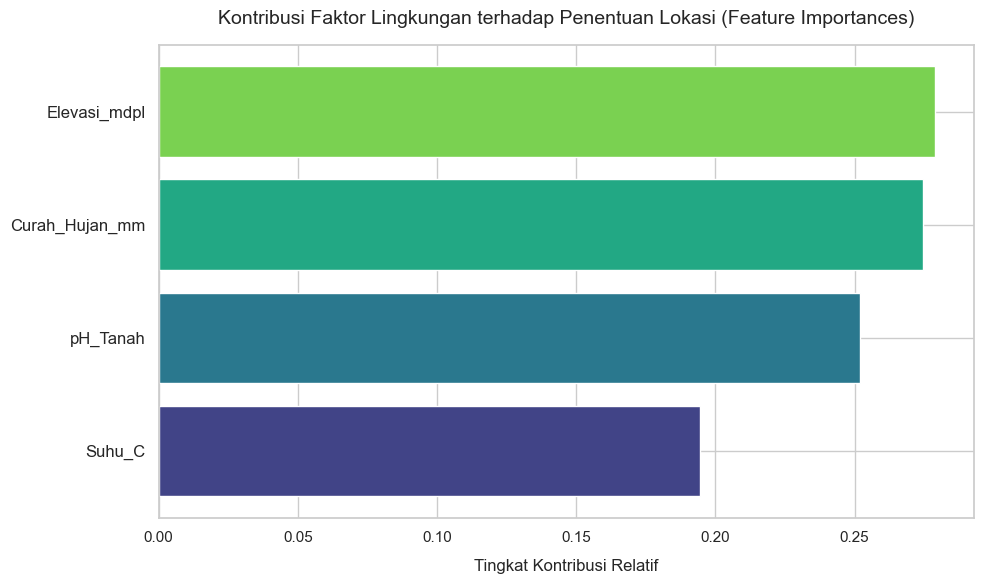

In [9]:
# Ambil bobot kontribusi fitur dari model
importances = rf_model.feature_importances_
indices = np.argsort(importances)

# Plot diagram batang horizontal
plt.figure(figsize=(10, 6))
plt.title('Kontribusi Faktor Lingkungan terhadap Penentuan Lokasi (Feature Importances)', fontsize=14, pad=15)
colors = sns.color_palette("viridis", len(feature_names))
plt.barh(range(len(indices)), importances[indices], align='center', color=colors)
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12)
plt.xlabel('Tingkat Kontribusi Relatif', fontsize=12, labelpad=10)
plt.tight_layout()
plt.show()

### B. Simulasi Rekomendasi Varietas Campuran (Hybrid Blended Recommendation)
Alur rekomendasi ini memprediksi kecocokan varietas dengan menggabungkan **60% Keyakinan Geografis Model** (Kecamatan probability distribution) dan **40% Kemiripan Karakteristik Iklim** (Euclidean Distance ternormalisasi Min-Max).

In [10]:
def recommend_varieties(ph, suhu, curah_hujan, elevasi):
    # 1. Siapkan input untuk prediksi
    input_df = pd.DataFrame([[ph, suhu, curah_hujan, elevasi]], 
                            columns=feature_names)
    
    # 2. Prediksi probabilitas tiap kecamatan menggunakan model
    probabilities = rf_model.predict_proba(input_df)[0]
    kec_names = le_kecamatan.classes_
    prob_map = dict(zip(kec_names, probabilities))
    
    best_kec = kec_names[np.argmax(probabilities)]
    confidence = np.max(probabilities)
    
    # 3. Normalisasi Min-Max sebagai acuan jarak similarity
    df_min = df[feature_names].min()
    df_max = df[feature_names].max()
    df_range = (df_max - df_min).replace(0, 1)
    
    normalized_input = (np.array([ph, suhu, curah_hujan, elevasi]) - df_min.values) / df_range.values
    
    # 4. Kelompokkan varietas untuk mendapatkan rata-rata parameter lingkungan pendukung
    variety_env = df.groupby(['Nama_Tanaman', 'Nama_Varietas'])[feature_names].mean().reset_index()
    variety_locs = df.groupby(['Nama_Tanaman', 'Nama_Varietas'])['Kecamatan'].unique().reset_index()
    variety_data = variety_env.merge(variety_locs, on=['Nama_Tanaman', 'Nama_Varietas'])
    
    # 5. Hitung Blended Score
    def calculate_score(row):
        # A. Location Score (bobot lokasi)
        location_score = sum(prob_map.get(k, 0) for k in row['Kecamatan'])
        
        # B. Similarity Score (jarak Euclidean)
        variety_features = (row[feature_names].values - df_min.values) / df_range.values
        dist = np.linalg.norm(normalized_input - variety_features)
        similarity_score = 1 / (1 + dist)
        
        # C. Blended Score (60% Bobot Lokasi Model, 40% Kemiripan Iklim)
        return (location_score * 0.6 + similarity_score * 0.4) * 0.98
    
    variety_data['Score'] = variety_data.apply(calculate_score, axis=1)
    
    # 6. Pilih varietas dengan nilai kecocokan tertinggi untuk masing-masing tanaman
    recommendations = variety_data.sort_values('Score', ascending=False).groupby('Nama_Tanaman').head(1).reset_index()
    
    print("="*70)
    print("HASIL SIMULASI SISTEM REKOMENDASI VARIETAS HORTIKULTURA")
    print("="*70)
    print(f"Kecamatan Terdekat Teridentifikasi : {best_kec}")
    print(f"Tingkat Keyakinan Geografis Model : {confidence * 100:.2f}%")
    print("="*70)
    print("\nRekomendasi Komoditas Terbaik:")
    for _, row in recommendations.sort_values('Nama_Tanaman').iterrows():
        print(f"- {row['Nama_Tanaman']:<18}: Varietas {row['Nama_Varietas']:<18} (Kecocokan: {row['Score']*100:.2f}%)")
    print("="*70)

# Simulasi input dari user
recommend_varieties(
    ph=6.46, 
    suhu=24.2, 
    curah_hujan=1763, 
    elevasi=255
)

HASIL SIMULASI SISTEM REKOMENDASI VARIETAS HORTIKULTURA
Kecamatan Terdekat Teridentifikasi : Dewantara
Tingkat Keyakinan Geografis Model : 19.00%

Rekomendasi Komoditas Terbaik:
- Bayam             : Varietas Bangkok            (Kecocokan: 75.18%)
- Cabe Besar        : Varietas Tanjung 2          (Kecocokan: 75.18%)
- Cabe Keriting     : Varietas TM 999             (Kecocokan: 75.18%)
- Cabe Rawit        : Varietas Taruna             (Kecocokan: 75.18%)
- Kacang Panjang    : Varietas Parade Tavi        (Kecocokan: 75.18%)
- Kangkung          : Varietas Sutra              (Kecocokan: 75.18%)
- Ketimun           : Varietas Roman F1           (Kecocokan: 75.18%)
- Semangka          : Varietas Sugar Baby         (Kecocokan: 75.18%)
- Terung            : Varietas Mustang F1         (Kecocokan: 75.18%)
- Tomat             : Varietas Ratna              (Kecocokan: 75.18%)
